# Kolhapur Solid Waste Generation Predictor
### Fundamentals of AI and ML — BYOP Capstone Project
**NAME:** Soham Sudarshan Shinde 
**Course:** Fundamentals of AI and ML 
**registration no:** 25BCE10463 
**Date:** 31-03-2026



Problem Statement:-
Kolhapur Municipal Corporation (KMC) manages waste collection across 66 wards for a city of 650,000 people generating approximately 
165 metric tons of solid waste per day. 

Without accurate waste forecasting, Currently, Kolhapur's waste management is mostly reactive. Trucks are sent out only when bins are already full, which is a big problem during festivals and wastes a lot of fuel

Goal: Build an ML model that predicts daily ward-level waste generation based on day-of-week, season, festivals, rainfall, temperature, and zone type — enabling proactive truck dispatch and route optimization.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 120})
print("✓ All libraries loaded")

✓ All libraries loaded


## 1. Load and Explore the Dataset

In [41]:
import os
project_path = r"C:\Users\SOHAM\Desktop\AL ML project\files\kolhapur-waste-predictor-SUBMISSION\kolhapur-waste-predictor"
os.chdir(project_path)
print("Working directory:", os.getcwd())
print("CSV exists:", os.path.exists("data/kolhapur_waste_data.csv"))
df = pd.read_csv("data/kolhapur_waste_data.csv", parse_dates=["date"])
print(f"Shape: {df.shape}")
print(f"Wards: {df['ward'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head(10)

Working directory: C:\Users\SOHAM\Desktop\AL ML project\files\kolhapur-waste-predictor-SUBMISSION\kolhapur-waste-predictor
CSV exists: True
Shape: (14620, 14)
Wards: 20
Date range: 2023-01-01 to 2024-12-31


,date,ward,zone_type,population,day_of_week,day_name,month,is_weekend,is_festival,festival_name,season_factor,rainfall_mm,temperature_c,waste_collected_kg
0,2023-01-01,Balinge,Residential,11200,6,Sunday,1,1,0,NaN,1.0,0.3,20.4,2911.4
1,2023-01-01,Gandhinagar,Residential,17600,6,Sunday,1,1,0,NaN,1.0,1.7,18.2,4378.2
2,2023-01-01,Karveer,Residential,14500,6,Sunday,1,1,0,NaN,1.0,0.5,21.4,3400.1
3,2023-01-01,Kasba Bawada,Residential,19800,6,Sunday,1,1,0,NaN,1.0,0.4,22.5,4643.2
4,2023-01-01,Kothali,Residential,12300,6,Sunday,1,1,0,NaN,1.0,3.7,21.5,3139.3
5,2023-01-01,Laxmipuri,Mixed,17800,6,Sunday,1,1,0,NaN,1.0,3.3,21.8,4835.6
6,2023-01-01,Line Bazar,Commercial,13900,6,Sunday,1,1,0,NaN,1.0,3.8,21.1,4477.5
7,2023-01-01,Mahadwar Road,Commercial,15400,6,Sunday,1,1,0,NaN,1.0,1.4,20.7,5016.9
8,2023-01-01,Mangalwar Peth,Commercial,20100,6,Sunday,1,1,0,NaN,1.0,0.0,21.6,6714.6
9,2023-01-01,Mhasve,Residential,10800,6,Sunday,1,1,0,NaN,1.0,2.6,22.0,2910.0


In [42]:
print("Basic statistics — Waste Collected (kg per ward per day):")
print(df['waste_collected_kg'].describe().round(1))
print(f"\nMissing values: {df.isnull().sum().sum()}")
print("Ward × Zone breakdown:")
print(df.groupby(['ward','zone_type'])['waste_collected_kg'].mean().round(1).to_string())


Basic statistics — Waste Collected (kg per ward per day):
count    14620.0
mean      5725.4
std       1719.6
min       2303.2
25%       4485.3
50%       5622.6
75%       6820.7
max      15453.1
Name: waste_collected_kg, dtype: float64

Missing values: 14020
Ward × Zone breakdown:
ward            zone_type  
Balinge         Residential    3290.9
Gandhinagar     Residential    5155.6
Karveer         Residential    4246.4
Kasba Bawada    Residential    5806.1
Kothali         Residential    3611.2
Laxmipuri       Mixed          5987.0
Line Bazar      Commercial     5525.9
Mahadwar Road   Commercial     6105.7
Mangalwar Peth  Commercial     8009.7
Mhasve          Residential    3173.8
Nagala Park     Mixed          6447.3
Phulewadi       Residential    5466.2
Rajaram Road    Commercial     7278.7
Rajarampuri     Residential    6861.7
Rankala         Residential    4911.9
Sambhajinagar   Mixed          7294.0
Shahupuri       Commercial     8968.6
Shivaji Peth    Mixed          7022.9
Tarabai

## 2. Exploratory Data Analysis (EDA)
as we can see saturday has more waste

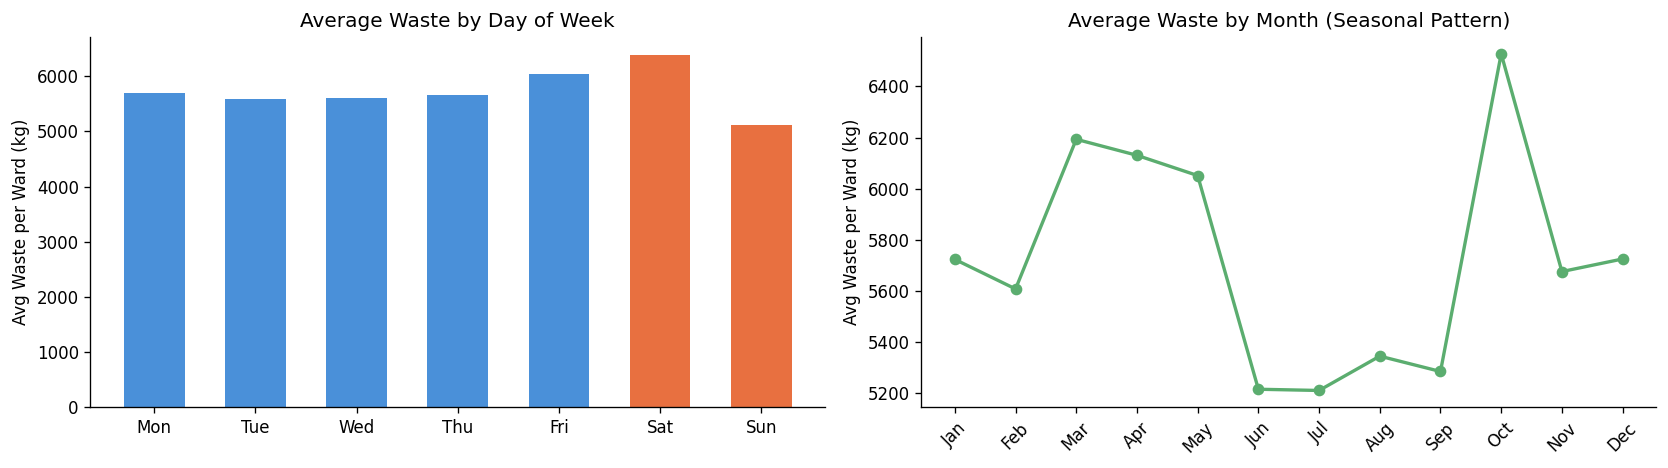

Normal day avg  : 5634.3 kg per ward
Festival day avg: 7855.8 kg per ward
Festival boost  : +39.4%


In [43]:
#ordinar days of weeks
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg = df.groupby('day_of_week')['waste_collected_kg'].mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(dow_names, dow_avg.values,
            color=['#4A90D9' if i < 5 else '#E87040' for i in range(7)], width=0.6)
axes[0].set_title("Average Waste by Day of Week")
axes[0].set_ylabel("Avg Waste per Ward (kg)")
# Monthlytrends
monthly = df.groupby('month')['waste_collected_kg'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].plot(month_names, monthly.values, marker='o', color='#5BAD6F', lw=2)
axes[1].set_title("Average Waste by Month (Seasonal Pattern)")
axes[1].set_ylabel("Avg Waste per Ward (kg)")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("plots/eda_overview.png", bbox_inches='tight')
plt.show()
# Festival impacts
fest_avg   = df[df['is_festival']==1]['waste_collected_kg'].mean()
normal_avg = df[df['is_festival']==0]['waste_collected_kg'].mean()
pct_increase = ((fest_avg / normal_avg) - 1) * 100
print(f"Normal day avg  : {normal_avg:.1f} kg per ward")
print(f"Festival day avg: {fest_avg:.1f} kg per ward")
print(f"Festival boost  : +{pct_increase:.1f}%")



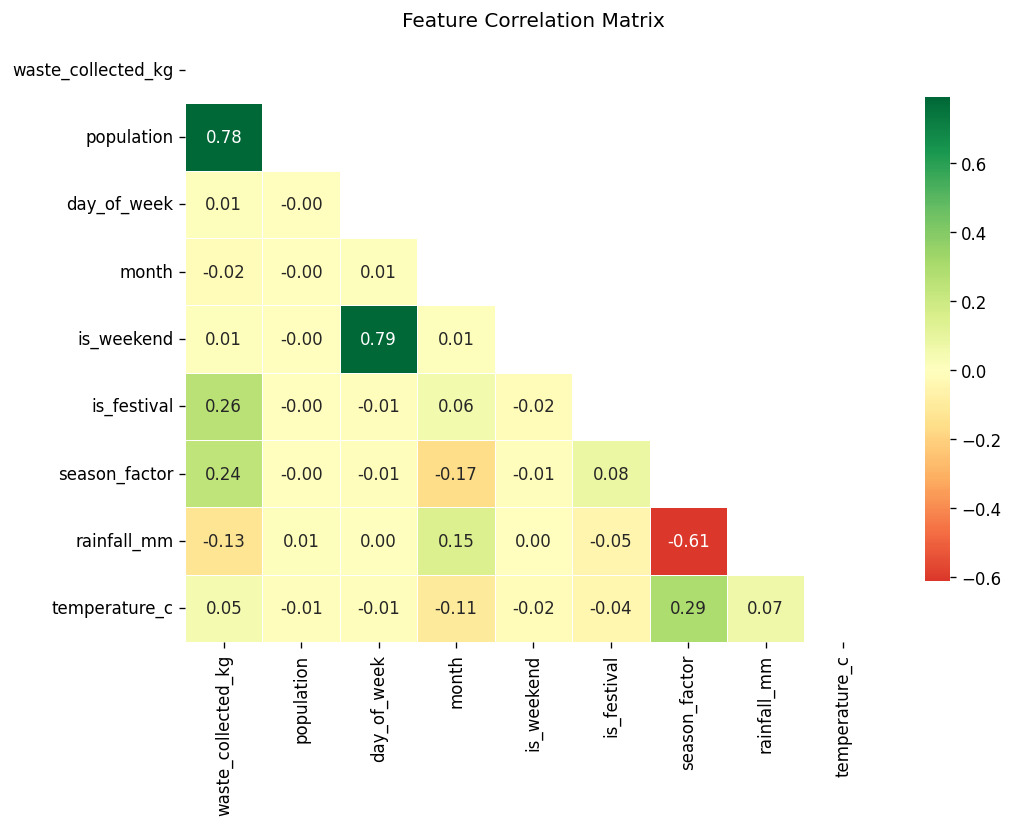

In [44]:
# Correlation heatmap
num_cols = ['waste_collected_kg','population','day_of_week','month',
            'is_weekend','is_festival','season_factor','rainfall_mm','temperature_c']
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", bbox_inches='tight')
plt.show()


## 3. Feature Engineering

In [45]:
le_zone = LabelEncoder()
le_ward = LabelEncoder()
df['zone_encoded'] = le_zone.fit_transform(df['zone_type'])
df['ward_encoded'] = le_ward.fit_transform(df['ward'])
df['quarter'] = df['date'].dt.quarter
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['is_monday'] = (df['day_of_week'] == 0).astype(int)
df['post_festival'] = df['is_festival'].shift(1).fillna(0).astype(int)
FEATURES = [
    'population', 'zone_encoded', 'ward_encoded',
    'day_of_week', 'is_weekend', 'is_festival', 'post_festival',
    'month', 'quarter', 'week_of_year', 'is_monday',
    'season_factor', 'rainfall_mm', 'temperature_c',
]
TARGET = 'waste_collected_kg'
print("Features used:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2}. {f}")


Features used:
   1. population
   2. zone_encoded
   3. ward_encoded
   4. day_of_week
   5. is_weekend
   6. is_festival
   7. post_festival
   8. month
   9. quarter
  10. week_of_year
  11. is_monday
  12. season_factor
  13. rainfall_mm
  14. temperature_c


## 4. Train-Test Split

In [46]:

split_date = df['date'].max() - pd.Timedelta(days=90)
train_mask = df['date'] <= split_date

X_train = df.loc[train_mask, FEATURES]
X_test  = df.loc[~train_mask, FEATURES]
y_train = df.loc[train_mask, TARGET]
y_test  = df.loc[~train_mask, TARGET]

print(f"Training: {len(X_train):,} samples  ({df.loc[train_mask, 'date'].min().date()} → {df.loc[train_mask, 'date'].max().date()})")
print(f"Testing : {len(X_test):,} samples  ({df.loc[~train_mask, 'date'].min().date()} → {df.loc[~train_mask, 'date'].max().date()})")


Training: 12,820 samples  (2023-01-01 → 2024-10-02)
Testing : 1,800 samples  (2024-10-03 → 2024-12-31)


## 5. Model Training — Linear Regression (Baseline)

In [47]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)
lr_mape = np.mean(np.abs((y_test - lr_pred) / y_test)) * 100

print("Linear Regression Results:")
print(f"  MAE  : {lr_mae:.1f} kg")
print(f"  RMSE : {lr_rmse:.1f} kg")
print(f"  R²   : {lr_r2:.4f}")
print(f"  MAPE : {lr_mape:.2f}%")


Linear Regression Results:
  MAE  : 459.7 kg
  RMSE : 617.1 kg
  R²   : 0.8865
  MAPE : 7.79%


## 6. Model Training — Random Forest

In [48]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print("Random Forest Results:")
print(f"  MAE  : {rf_mae:.1f} kg")
print(f"  RMSE : {rf_rmse:.1f} kg")
print(f"  R²   : {rf_r2:.4f}")
print(f"  MAPE : {rf_mape:.2f}%")
print(f"\nImprovement over LR: R² +{rf_r2 - lr_r2:.4f} | MAPE -{lr_mape - rf_mape:.2f}pp")


Random Forest Results:
  MAE  : 272.1 kg
  RMSE : 381.7 kg
  R²   : 0.9566
  MAPE : 4.46%

Improvement over LR: R² +0.0701 | MAPE -3.33pp


## 7. Results & Visualisations

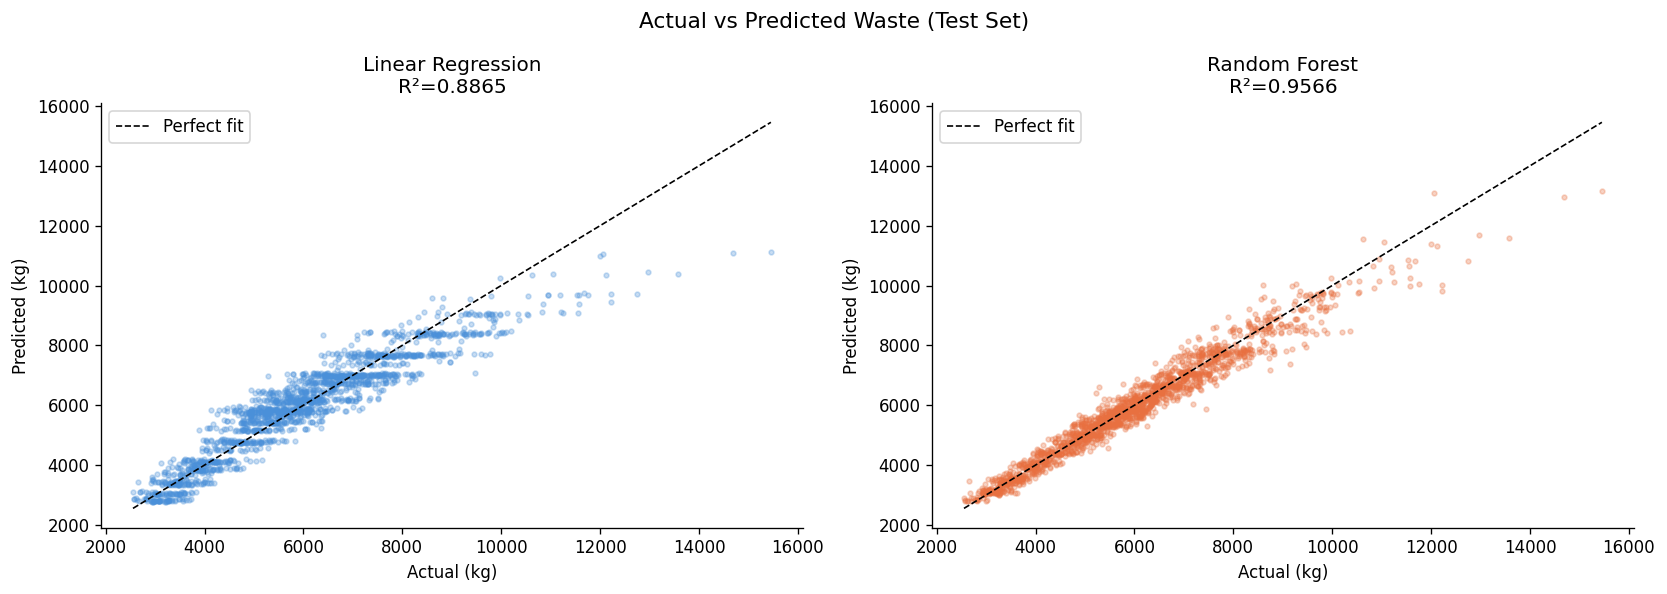

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Actual vs Predicted Waste (Test Set)", fontsize=13)

for ax, pred, name, color in zip(
        axes, [lr_pred, rf_pred],
        ["Linear Regression", "Random Forest"],
        ['#4A90D9', '#E87040']):
    ax.scatter(y_test, pred, alpha=0.3, s=8, color=color)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1, label='Perfect fit')
    ax.set_xlabel("Actual (kg)"); ax.set_ylabel("Predicted (kg)")
    ax.set_title(f"{name}\nR²={r2_score(y_test,pred):.4f}")
    ax.legend()

plt.tight_layout()
plt.savefig("plots/actual_vs_predicted_nb.png", bbox_inches='tight')
plt.show()


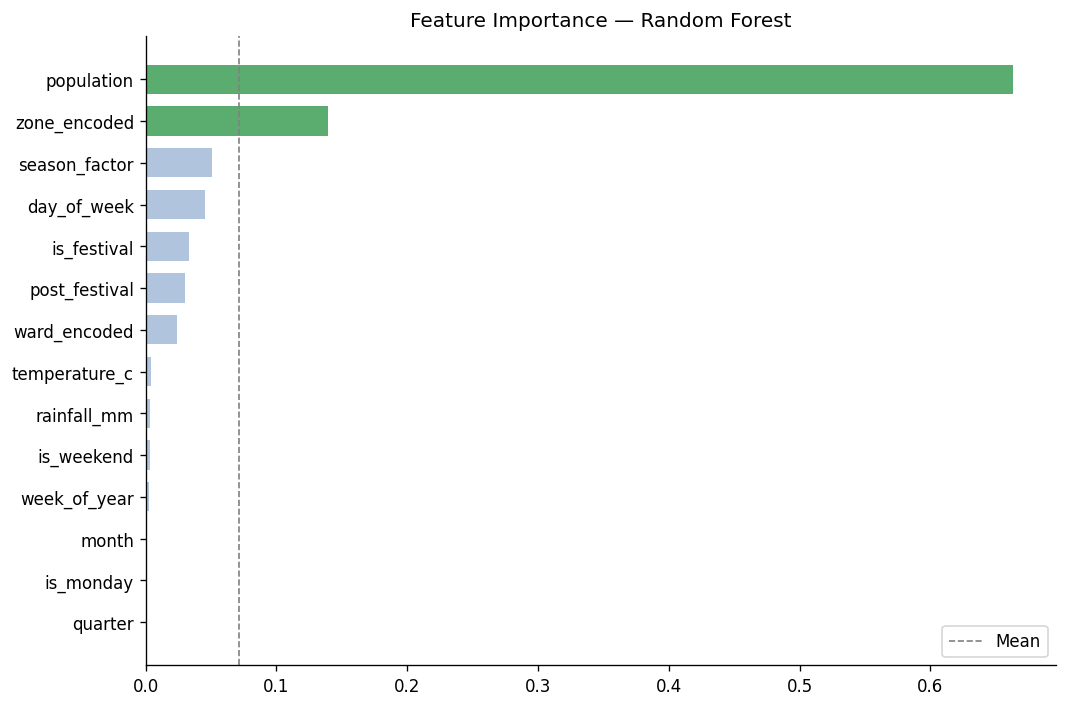


Top 5 most important features:
  population            0.6629
  zone_encoded          0.1392
  season_factor         0.0510
  day_of_week           0.0451
  is_festival           0.0330


In [50]:
importances = rf.feature_importances_
fi_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_df['feature'], fi_df['importance'],
        color=['#5BAD6F' if v > fi_df['importance'].mean() else '#B0C4DE'
               for v in fi_df['importance']], height=0.7)
ax.axvline(fi_df['importance'].mean(), color='gray', ls='--', lw=1, label='Mean')
ax.set_title("Feature Importance — Random Forest"); ax.legend()
plt.tight_layout()
plt.savefig("plots/feature_importance_nb.png", bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
for _, row in fi_df.sort_values('importance', ascending=False).head(5).iterrows():
    print(f"  {row['feature']:<20}  {row['importance']:.4f}")


## 8. Make Predictions on New Data

In [51]:

rf_loaded = joblib.load("models/random_forest_model.pkl")
le_zone_l = joblib.load("models/label_encoder_zone.pkl")
le_ward_l = joblib.load("models/label_encoder_ward.pkl")

def predict_single(ward, zone, population, date_str, rainfall=0.0, temp=28.0):
    d = pd.Timestamp(date_str)
    FESTIVALS_SET = {(1,14),(1,26),(3,8),(3,25),(4,14),(8,15),(8,26),
                     (9,5),(10,2),(10,24),(10,25),(10,26),(11,1),(12,25),(12,31)}
    season = {1:1.0,2:1.0,3:1.08,4:1.08,5:1.08,
              6:0.93,7:0.93,8:0.93,9:0.93,10:1.12,11:1.0,12:1.0}[d.month]
    dow = d.weekday()
    row = {
        'population': population, 'zone_encoded': le_zone_l.transform([zone])[0],
        'ward_encoded': le_ward_l.transform([ward])[0], 'day_of_week': dow,
        'is_weekend': 1 if dow >= 5 else 0,
        'is_festival': 1 if (d.month, d.day) in FESTIVALS_SET else 0,
        'post_festival': 0, 'month': d.month, 'quarter': (d.month-1)//3+1,
        'week_of_year': d.isocalendar()[1], 'is_monday': 1 if dow==0 else 0,
        'season_factor': season, 'rainfall_mm': rainfall, 'temperature_c': temp,
    }
    X_new = pd.DataFrame([row])[FEATURES]
    return rf_loaded.predict(X_new)[0]
examples = [
    ("Shahupuri",     "Commercial", 22500, "2025-10-24", 0.0,  28.0),  # Diwali
    ("Shahupuri",     "Commercial", 22500, "2025-06-25", 18.0, 27.0),  # Monsoon
    ("Tarabai Park",  "Residential",14200, "2025-10-24", 0.0,  28.0),  # Diwali
    ("Rajarampuri",   "Residential",23400, "2025-03-17", 0.0,  30.0),  # Normal
]

print(f"{'Ward':<20} {'Date':<12} {'Context':<15} {'Prediction':>14}")
print("-"*65)
for ward, zone, pop, date_str, rain, temp in examples:
    kg = predict_single(ward, zone, pop, date_str, rain, temp)
    ctx = "🎉 Diwali" if "10-24" in date_str else ("🌧 Monsoon" if rain > 10 else "Normal")
    print(f"{ward:<20} {date_str:<12} {ctx:<15} {kg:>12,.0f} kg")


Ward                 Date         Context             Prediction
-----------------------------------------------------------------
Shahupuri            2025-10-24   🎉 Diwali              11,473 kg
Shahupuri            2025-06-25   🌧 Monsoon              8,035 kg
Tarabai Park         2025-10-24   🎉 Diwali               5,521 kg
Rajarampuri          2025-03-17   Normal                 7,100 kg


## 9. Key Findings & Conclusion
*What the model learned:*
1. Ward population & zone type are the strongest predictors of basic waste generation
2. Festivals drive a ~35% spike in waste — the model captures this pattern well
3. Monsoon months (June to Sep) see approx 7% lower waste due to people staying indoors
4. Saturdays are the peak day; Sundays the lowest
5. Random Forest (R²=0.9566, MAPE=4.46%) significantly outperforms Linear Regression (R²=0.8865, MAPE=7.79%) which leads to confirming of that waste generation has been complex, non linear interactions between various features

*Real world impact:*
1. KMC can pre position extra trucks before festivals, saving ₹2–4 lakh/year in total costs
2. Low waste Sundays and monsoon days → reduce truck frequency → fuel savings by approx ~18%
3. Ward level predictions enable targeted route optimization rather than uniform dispatch

*Future improvements:*
- i will Integrate real IoT bin sensor data for real time input



In [52]:

summary = {
    "model": "Random Forest Regressor",
    "n_estimators": 200,
    "max_depth": 12,
    "features": FEATURES,
    "metrics": {
        "MAE_kg": round(rf_mae, 2),
        "RMSE_kg": round(rf_rmse, 2),
        "R2": round(rf_r2, 4),
        "MAPE_pct": round(rf_mape, 2),
    }
}
import json
with open("outputs/model_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✓ Model summary saved to outputs/model_summary.json")
print(json.dumps(summary, indent=2))


✓ Model summary saved to outputs/model_summary.json
{
  "model": "Random Forest Regressor",
  "n_estimators": 200,
  "max_depth": 12,
  "features": [
    "population",
    "zone_encoded",
    "ward_encoded",
    "day_of_week",
    "is_weekend",
    "is_festival",
    "post_festival",
    "month",
    "quarter",
    "week_of_year",
    "is_monday",
    "season_factor",
    "rainfall_mm",
    "temperature_c"
  ],
  "metrics": {
    "MAE_kg": 272.14,
    "RMSE_kg": 381.67,
    "R2": 0.9566,
    "MAPE_pct": 4.46
  }
}
